In [23]:
import pandas as pd

In [49]:
epic = "IX.D.CAC.IMF.IP"
df = pd.read_csv(f'opening_ranges_2022_{epic}.csv', index_col='utc_time', parse_dates=True)

In [50]:
df.head()

,1min_bid_high,1min_ask_high,1min_bid_low,1min_ask_low,5min_bid_high,5min_ask_high,5min_bid_low,5min_ask_low
utc_time,,,,,,,,
2022-04-26 07:00:00,6522.0,6523.5,6500.7,6501.7,6522.0,6523.5,6488.0,6489.0
2022-04-27 07:00:00,6429.2,6430.2,6418.7,6419.7,6434.4,6435.4,6409.4,6410.4
2022-04-28 07:00:00,6523.5,6524.5,6515.5,6516.5,6524.2,6525.2,6509.5,6510.5
2022-04-29 07:00:00,6560.2,6561.2,6551.0,6552.0,6560.5,6561.5,6543.7,6544.7
2022-05-02 07:00:00,6471.4,6472.4,6458.7,6459.7,6472.9,6473.9,6458.7,6459.7


### Distribution 1 Minute Opening Range

<AxesSubplot:ylabel='Frequency'>

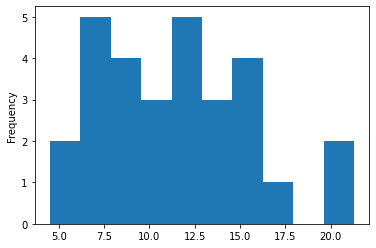

In [51]:
min1 = df['1min_bid_high'] - df['1min_bid_low']
min1.plot.hist()

### Distribution 5 Minute Opening Range

<AxesSubplot:ylabel='Frequency'>

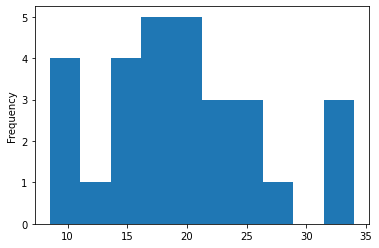

In [52]:
min5 = df['5min_bid_high'] - df['5min_bid_low']
min5.plot.hist()

### Distribution Spread

<AxesSubplot:ylabel='Frequency'>

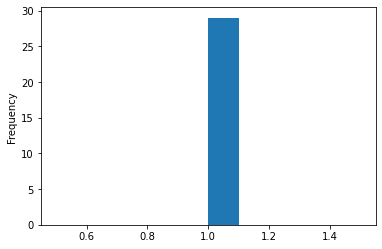

In [53]:
min5 = df['5min_ask_low'] - df['5min_bid_low']
min5.plot.hist()

1/3 5min range inside 1min
- How if my 5min opening range stop is outside reach of 1min range will be better is my theory 

In [54]:
df['5min1R'] = ((df['5min_bid_high'] - df['5min_bid_low']) -1) / 3

In [55]:
df['high_stop_lower'] = (df['5min_bid_high'] - df['5min1R']) < df['1min_bid_high']
df['high_stop_lower'].value_counts()

True     23
False     6
Name: high_stop_lower, dtype: int64

In [56]:
df['low_stop_higher'] = (df['5min_bid_low'] + df['5min1R']) > df['1min_bid_low']
df['low_stop_higher'].value_counts()

True     16
False    13
Name: low_stop_higher, dtype: int64